<div style="padding:20px;background:linear-gradient(90deg,#0f0c29 0%,#302b63 50%,#24243e 100%);border-radius:10px;color:white;">
    <h1 style="color:white;border-bottom:none;">🎓 Module 10: Capstone — End-to-End Production RAG System</h1>
    <p style="font-size:1.2em;opacity:0.9;">Assembling every concept from the curriculum into one cohesive pipeline.</p>
</div>

---

### Project Essence
- **What it is**: A professional-grade, agentic RAG (Retrieval-Augmented Generation) system designed for production scalability.
- **What it does**: Automates the entire RAG lifecycle—from document ingestion and hybrid searching to intelligent answer generation with source citations and self-correction.
- **How it works**: It employs a **LangGraph-driven state machine** that classifies query complexity, performs multi-stage retrieval (BM25 + Vector), grades document relevance, and autonomously rewrites queries if initial retrieval is insufficient.


## Architecture Overview
```
┌───────────────────┬────────────────────┬────────────────────┐
│   INGESTION       │   RETRIEVAL        │   GENERATION       │
│───────────────────│────────────────────│────────────────────│
│ Text Splitter     │ BM25 (sparse)      │ LangGraph Agent    │
│ Metadata Enrich   │ Chroma (dense)     │ Query Classify     │
│ Chroma Index      │ CrossEncoder       │ Grade + Rewrite    │
└───────────────────┴────────────────────┴────────────────────┘
```

**Tech Stack**: `ChatGroq` (llama-3.1-8b-instant) + `HuggingFaceEmbeddings` (all-MiniLM-L6-v2) — 100% free.

In [9]:
import os, hashlib, warnings
from datetime import datetime
from dotenv import load_dotenv

warnings.filterwarnings('ignore')
os.environ['TOKENIZERS_PARALLELISM'] = 'false'
load_dotenv()

assert os.getenv('GROQ_API_KEY'), 'Set GROQ_API_KEY in your .env file'
print('✅ Environment loaded')

✅ Environment loaded


## Step 1 — Ingestion Pipeline

We create a sample corpus of 6 documents covering core RAG topics, split them into chunks, enrich metadata, and index into Chroma.

In [10]:
from langchain_core.documents import Document
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_community.vectorstores import Chroma
from langchain_huggingface import HuggingFaceEmbeddings

RAW_CORPUS = [
    Document(page_content="Retrieval-Augmented Generation (RAG) enhances LLMs by retrieving relevant external documents at inference time. RAG addresses static knowledge cutoffs and hallucination.", metadata={"source":"rag_overview.txt","year":2024}),
    Document(page_content="LangChain provides abstractions for document loaders, text splitters, embeddings, vector stores, retrievers, chains, and agents. LangGraph extends it with graph-based state machines.", metadata={"source":"langchain_overview.txt","year":2024}),
    Document(page_content="Vector stores index high-dimensional embeddings and support fast approximate nearest neighbour search. Popular choices include Chroma, FAISS, Qdrant, and Pinecone.", metadata={"source":"vector_stores.txt","year":2024}),
    Document(page_content="Hybrid search combines dense semantic and sparse keyword retrieval. BM25 matches exact keywords while dense vectors capture semantic similarity. Reciprocal Rank Fusion merges results.", metadata={"source":"hybrid_search.txt","year":2024}),
    Document(page_content="RAGAS evaluates RAG pipelines without human annotations. Key metrics: Faithfulness, Answer Relevancy, Context Precision, Context Recall.", metadata={"source":"ragas_guide.txt","year":2024}),
    Document(page_content="Advanced RAG patterns: RAG Fusion generates multiple query variants merged via RRF. HyDE generates hypothetical answers for retrieval. Corrective RAG grades docs and falls back to web search. Self-RAG uses reflection tokens.", metadata={"source":"advanced_rag.txt","year":2024}),
]

splitter = RecursiveCharacterTextSplitter(chunk_size=300, chunk_overlap=50, add_start_index=True)
chunks = splitter.split_documents(RAW_CORPUS)

enriched = []
for i, c in enumerate(chunks):
    meta = {**c.metadata, "chunk_id": hashlib.md5(c.page_content.encode()).hexdigest()[:8], "chunk_index": i, "ingested_at": datetime.utcnow().isoformat()}
    enriched.append(Document(page_content=c.page_content, metadata=meta))

print(f'📄 Raw docs: {len(RAW_CORPUS)} | Chunks: {len(enriched)}')
for c in enriched[:3]:
    print(f'  [{c.metadata["chunk_id"]}] {c.page_content[:70]}...')

📄 Raw docs: 6 | Chunks: 6
  [8d521b5a] Retrieval-Augmented Generation (RAG) enhances LLMs by retrieving relev...
  [1b9109db] LangChain provides abstractions for document loaders, text splitters, ...
  [2c25d756] Vector stores index high-dimensional embeddings and support fast appro...


In [11]:
embeddings = HuggingFaceEmbeddings(model_name='all-MiniLM-L6-v2')
vectorstore = Chroma.from_documents(enriched, embeddings, collection_name='capstone_v2')
print(f'✅ Indexed {len(enriched)} chunks into Chroma')

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

✅ Indexed 6 chunks into Chroma


## Step 2 — Hybrid Retriever with Re-ranking

We combine BM25 (sparse keyword) + Chroma (dense semantic) results, then use a CrossEncoder re-ranker for precision.

In [12]:
from langchain_community.retrievers import BM25Retriever
from sentence_transformers import CrossEncoder

bm25 = BM25Retriever.from_documents(enriched, k=5)
dense = vectorstore.as_retriever(search_kwargs={'k': 5})
cross_encoder = CrossEncoder('cross-encoder/ms-marco-TinyBERT-L-2-v2')

def retrieve_and_rerank(query, top_n=3):
    sparse_docs = bm25.invoke(query)
    dense_docs = dense.invoke(query)
    seen, combined = set(), []
    for d in dense_docs + sparse_docs:
        key = d.page_content[:80]
        if key not in seen:
            seen.add(key)
            combined.append(d)
    if not combined:
        return []
    pairs = [(query, d.page_content) for d in combined]
    scores = cross_encoder.predict(pairs)
    ranked = sorted(zip(scores, combined), reverse=True)
    return [d for _, d in ranked[:top_n]]

test_q = 'How does hybrid search improve retrieval?'
results = retrieve_and_rerank(test_q)
print(f'Query: "{test_q}"\nTop-{len(results)} after re-ranking:')
for i, d in enumerate(results, 1):
    print(f'  [{i}] ({d.metadata["source"]}) {d.page_content[:90]}...')

Loading weights:   0%|          | 0/41 [00:00<?, ?it/s]

Query: "How does hybrid search improve retrieval?"
Top-3 after re-ranking:
  [1] (hybrid_search.txt) Hybrid search combines dense semantic and sparse keyword retrieval. BM25 matches exact key...
  [2] (rag_overview.txt) Retrieval-Augmented Generation (RAG) enhances LLMs by retrieving relevant external documen...
  [3] (advanced_rag.txt) Advanced RAG patterns: RAG Fusion generates multiple query variants merged via RRF. HyDE g...


## Step 3 — Agentic RAG with LangGraph

We build a full state machine that classifies query complexity, retrieves, grades, rewrites, and generates with citations.

In [13]:
from typing import TypedDict, List
from langgraph.graph import StateGraph, END
from langchain_groq import ChatGroq
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.output_parsers import StrOutputParser

llm = ChatGroq(model='llama-3.1-8b-instant', temperature=0)

class RAGState(TypedDict):
    question: str
    complexity: str
    documents: List[Document]
    relevance_grade: str
    rewritten_query: str
    iterations: int
    answer: str
    citations: List[str]

def classify_node(state):
    p = ChatPromptTemplate.from_template("Is this 'simple' or 'complex' (needs docs)? Answer one word.\nQ: {question}")
    r = (p | llm | StrOutputParser()).invoke({'question': state['question']})
    return {**state, 'complexity': 'complex' if 'complex' in r.lower() else 'simple'}

def retrieve_node(state):
    q = state.get('rewritten_query') or state['question']
    docs = retrieve_and_rerank(q, top_n=3)
    return {**state, 'documents': docs, 'iterations': state.get('iterations',0)+1}

def grade_node(state):
    p = ChatPromptTemplate.from_template("Is this doc relevant to '{question}'? yes/no.\nDoc: {doc}")
    chain = p | llm | StrOutputParser()
    rel = [d for d in state['documents'] if 'yes' in chain.invoke({'question':state['question'],'doc':d.page_content[:200]}).lower()]
    grade = 'relevant' if rel else 'irrelevant'
    return {**state, 'documents': rel or state['documents'], 'relevance_grade': grade}

def rewrite_node(state):
    p = ChatPromptTemplate.from_template('Rewrite for better retrieval: {question}')
    rw = (p | llm | StrOutputParser()).invoke({'question': state['question']})
    return {**state, 'rewritten_query': rw.strip()}

def direct_node(state):
    p = ChatPromptTemplate.from_template('Answer concisely: {question}')
    a = (p | llm | StrOutputParser()).invoke({'question': state['question']})
    return {**state, 'answer': a, 'citations': []}

def generate_node(state):
    parts, cites = [], []
    for i, d in enumerate(state['documents'], 1):
        parts.append(f'[{i}] {d.page_content}')
        cites.append(d.metadata.get('source', f'doc_{i}'))
    ctx = '\n\n'.join(parts)
    p = ChatPromptTemplate.from_template('Answer ONLY using context. Cite as [N].\nContext:\n{context}\nQ: {question}')
    a = (p | llm | StrOutputParser()).invoke({'context': ctx, 'question': state['question']})
    return {**state, 'answer': a, 'citations': cites}

def route_complexity(state): return 'direct' if state['complexity']=='simple' else 'retrieve'
def route_grade(state):
    if state['relevance_grade']=='relevant' or state.get('iterations',0)>=2: return 'generate'
    return 'rewrite'

b = StateGraph(RAGState)
b.add_node('classify', classify_node)
b.add_node('retrieve', retrieve_node)
b.add_node('grade', grade_node)
b.add_node('rewrite', rewrite_node)
b.add_node('direct', direct_node)
b.add_node('generate', generate_node)
b.set_entry_point('classify')
b.add_conditional_edges('classify', route_complexity, {'direct':'direct','retrieve':'retrieve'})
b.add_edge('retrieve','grade')
b.add_conditional_edges('grade', route_grade, {'generate':'generate','rewrite':'rewrite'})
b.add_edge('rewrite','retrieve')
b.add_edge('direct', END)
b.add_edge('generate', END)
pipeline = b.compile()
print('✅ LangGraph pipeline compiled')

✅ LangGraph pipeline compiled


### 3.1 — Visualizing the Workflow

Understanding the state machine's logic is easier with a visual flow graph. This shows how queries are routed between nodes like `classify`, `retrieve`, `grade`, and `rewrite`.

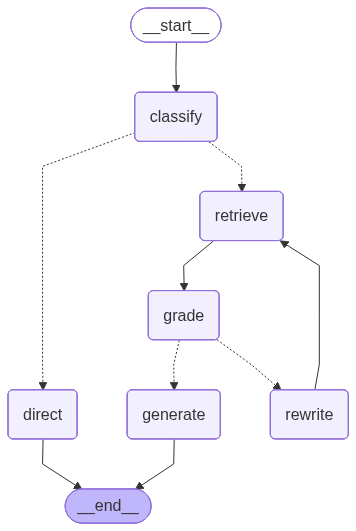

In [14]:
from IPython.display import Image, display

try:
    # Generate and display the graph as PNG
    # Note: Requires 'pygraphviz' or 'mermaid.cli' for PNG generation
    display(Image(pipeline.get_graph().draw_mermaid_png()))
except Exception:
    # Fallback to Mermaid text if PNG generation fails
    print("Graph visualization (PNG) not available. Showing Mermaid representation instead:")
    print(pipeline.get_graph().draw_mermaid())

In [15]:
def run(question):
    result = pipeline.invoke({'question':question,'complexity':'','documents':[],'relevance_grade':'','rewritten_query':'','iterations':0,'answer':'','citations':[]})
    print(f'\n{"="*60}')
    print(f'Q: {question}')
    print(f'  Complexity : {result["complexity"]}')
    print(f'  Iterations : {result["iterations"]}')
    if result['citations']: print(f'  Sources    : {", ".join(set(result["citations"]))}')
    print(f'  Answer     : {result["answer"][:300]}')
    return result

run('What is 2 + 2?')
run('How does RAGAS evaluate a RAG pipeline?')


Q: What is 2 + 2?
  Complexity : simple
  Iterations : 0
  Answer     : 4.

Q: How does RAGAS evaluate a RAG pipeline?
  Complexity : complex
  Iterations : 1
  Sources    : ragas_guide.txt
  Answer     : RAGAS evaluates a RAG pipeline without human annotations [1].


{'question': 'How does RAGAS evaluate a RAG pipeline?',
 'complexity': 'complex',
 'documents': [Document(metadata={'year': 2024, 'chunk_id': 'd6cf53d1', 'start_index': 0, 'chunk_index': 4, 'ingested_at': '2026-05-10T13:42:35.482313', 'source': 'ragas_guide.txt'}, page_content='RAGAS evaluates RAG pipelines without human annotations. Key metrics: Faithfulness, Answer Relevancy, Context Precision, Context Recall.')],
 'relevance_grade': 'relevant',
 'rewritten_query': '',
 'iterations': 1,
 'answer': 'RAGAS evaluates a RAG pipeline without human annotations [1].',
 'citations': ['ragas_guide.txt']}

## Step 4 — LLM-as-Judge Evaluation

We use our own ChatGroq-based judge to score Faithfulness, Answer Relevancy, and Context Precision on the pipeline outputs.

In [16]:
def score_metric(prompt_template, **kwargs):
    p = ChatPromptTemplate.from_template(prompt_template)
    r = (p | llm | StrOutputParser()).invoke(kwargs)
    return 1.0 if 'yes' in r.lower() else 0.0

eval_qs = [
    'What is RAG and why is it used?',
    'What advanced RAG patterns exist?',
]

eval_results = []
for q in eval_qs:
    r = run(q)
    ctx = '\n'.join(d.page_content for d in r.get('documents',[]))
    faith = score_metric('Is this answer fully supported by the context? yes/no.\nContext: {context}\nAnswer: {answer}', context=ctx, answer=r['answer'])
    relev = score_metric('Does this answer address the question? yes/no.\nQuestion: {question}\nAnswer: {answer}', question=q, answer=r['answer'])
    eval_results.append({'q': q, 'faith': faith, 'relev': relev})

print('\n' + '='*60)
print('📊 EVALUATION REPORT')
print('='*60)
for e in eval_results:
    print(f'  Q: {e["q"][:50]}')
    print(f'    Faithfulness: {e["faith"]:.1f} | Relevancy: {e["relev"]:.1f}')

avg_f = sum(e['faith'] for e in eval_results)/len(eval_results)
avg_r = sum(e['relev'] for e in eval_results)/len(eval_results)
print(f'\nMean Faithfulness: {avg_f:.2f} | Mean Relevancy: {avg_r:.2f}')


Q: What is RAG and why is it used?
  Complexity : simple
  Iterations : 0
  Answer     : RAG stands for Red, Amber, Green. It's a traffic light system used to indicate the status of tasks, projects, or issues. 

- Red (R): Indicates a problem or issue that needs immediate attention.
- Amber (A): Signals a warning or a potential issue that requires monitoring.
- Green (G): Represents a t

Q: What advanced RAG patterns exist?
  Complexity : complex
  Iterations : 1
  Sources    : rag_overview.txt, advanced_rag.txt
  Answer     : RAG Fusion, HyDE, Corrective RAG, and Self-RAG [1].

📊 EVALUATION REPORT
  Q: What is RAG and why is it used?
    Faithfulness: 1.0 | Relevancy: 1.0
  Q: What advanced RAG patterns exist?
    Faithfulness: 0.0 | Relevancy: 1.0

Mean Faithfulness: 0.50 | Mean Relevancy: 1.00


## Step 5 — Production Improvements Checklist

| Low Metric | Root Cause | Fix |
|---|---|---|
| Faithfulness < 0.7 | LLM hallucinating | Stricter prompt: 'ONLY use context' |
| Relevancy < 0.7 | Prompt too vague | Sharpen the answer prompt |
| Context Precision < 0.7 | Noisy chunks | Reduce chunk size or add filter |